# Atividade 02 - Sintonia do Filtro de Kalman

Curso: Sistemas Inteligentes - 2026.1

Aluno: Mateus Pincho de Oliveira

Data: 16 de Abril de 2026

## Descrição da Atividade: 

1. Implemente o método de sintonia proposto no artigo "On the Identification of Noise Covariances and Adaptive Kalman Filtering: A New Look at a 50 Year-Old Problem" para o caso do sistema descrito em  "Computer application for testing Kalman filter".

### Referência:

Zhang, L., Sidoti, D., Bienkowski, A., Pattipati, K. R., Bar-Shalom, Y., & Kleinman, D. L. (2020). *On the Identification of Noise Covariances and Adaptive Kalman Filtering: A New Look at a 50 Year-Old Problem*. IEEE Access, Vol. 8, pp. 59362-59388. DOI: 10.1109/ACCESS.2020.2982407

## 1. Introdução e Declaração do Problema

O filtro de Kalman (KF) é o estimador de estado ótimo para sistemas dinâmicos lineares excitados por ruído branco Gaussiano. No entanto, sua otimalidade requer **conhecimento exato** da covariância do ruído de processo $Q$ e da covariância do ruído de medição $R$. Na prática, essas quase nunca são conhecidas exatamente. Valores mal escolhidos de $Q$ e $R$ levam a estimativas de estado subótimas, inovações enviesadas e filtros inconsistentes.

O artigo de referência fornece:
1. Uma **condição de identificabilidade necessária e suficiente** para $Q$ e $R$ por meio de uma condição de posto em uma matriz de identificabilidade de covariância de ruído $\mathscr{I}$.
2. Um **novo algoritmo iterativo de seis etapas** que estima $W$, $S$, $R$, $Q$, $\bar{P}$ e $P$ usando uma abordagem de aproximação sucessiva com descida de gradiente adaptativa.
3. **Cinco fórmulas equivalentes (R1-R5)** para estimar $R$ usando resíduos pós-ajuste.
4. **Estimação acoplada iterativa de $Q$ e $P$** com imposição de restrições estruturais.

---

## 2. Modelo do Sistema

### 2.1 Modelo da Planta e de Medição

Considere o sistema dinâmico linear de tempo discreto:

$$x(k+1) = F x(k) + \Gamma v(k) \tag{1}$$

$$z(k) = H x(k) + w(k) \tag{2}$$

onde:
- $x(k) \in \mathbb{R}^{n_x}$: vetor de estado
- $z(k) \in \mathbb{R}^{n_z}$: vetor de medição
- $v(k) \in \mathbb{R}^{n_v}$: ruído de processo, $v(k) \sim \mathcal{N}(0, Q)$
- $w(k) \in \mathbb{R}^{n_z}$: ruído de medição, $w(k) \sim \mathcal{N}(0, R)$
- $F \in \mathbb{R}^{n_x \times n_x}$: matriz de transição de estado (conhecida)
- $H \in \mathbb{R}^{n_z \times n_x}$: matriz de medição (conhecida)
- $\Gamma \in \mathbb{R}^{n_x \times n_v}$: matriz de ganho de ruído de processo (conhecida)
- $Q \in \mathbb{R}^{n_v \times n_v}$: covariância do ruído de processo (**desconhecida**, semi-definida positiva)
- $R \in \mathbb{R}^{n_z \times n_z}$: covariância do ruído de medição (**desconhecida**, definida positiva)

As sequências de ruído $v(k)$ e $w(k)$ são de média zero, brancas, mutuamente independentes e independentes do estado inicial. Assume-se que o sistema é observável e $(F, \Gamma Q^{1/2})$ controlável.

### 2.2 Equações Padrão do Filtro de Kalman

**Predição:**

$$\hat{x}(k+1|k) = F \hat{x}(k|k) \tag{3}$$

$$P(k+1|k) = F P(k|k) F' + \Gamma Q \Gamma' \tag{7}$$

**Inovação:**

$$\nu(k+1) = z(k+1) - H \hat{x}(k+1|k) \tag{4}$$

**Covariância da inovação:**

$$S(k+1) = H P(k+1|k) H' + R \tag{7}$$

**Ganho de Kalman:**

$$W(k+1) = P(k+1|k) H' S(k+1)^{-1} \tag{8}$$

**Atualização (atualização de medição):**

$$\hat{x}(k+1|k+1) = \hat{x}(k+1|k) + W(k+1) \nu(k+1) \tag{5}$$

**Covariância de estado atualizada:**

$$P(k+1|k+1) = P(k+1|k) - W(k+1) S(k+1) W(k+1)' \tag{9}$$

---

## 3. Filtro de Kalman em Estado Estacionário

A abordagem de seis etapas neste artigo é projetada para um filtro de Kalman em **estado estacionário**, onde o ganho $W$ é constante ao longo do tempo.

### 3.1 Covariância de Predição em Estado Estacionário (DARE)

A covariância de predição em estado estacionário $\bar{P}$ satisfaz a **Equação Algébrica de Riccati Discreta** (DARE):

$$\bar{P} = F[\bar{P} - \bar{P}H'(H\bar{P}H' + R)^{-1}H\bar{P}]F' + \Gamma Q \Gamma' \tag{10}$$

### 3.2 Covariância Atualizada em Estado Estacionário

A covariância atualizada em estado estacionário $P$ satisfaz (ver Apêndice A):

$$P = \bar{P} - W S W' \tag{12}$$

Ou equivalentemente:

$$P = (I_{n_x} - WH)\bar{P}(I_{n_x} - WH)' + WRW' \tag{13}$$

Também pode ser computada como:

$$P = \left(\bar{P}^{-1} + H'R^{-1}H\right)^{-1} \tag{Apêndice A: 220}$$

### 3.3 Ganho em Estado Estacionário e Covariância da Inovação

$$W = \bar{P}H'S^{-1} = PH'R^{-1} \tag{14}$$

$$S = E[\nu(k)\nu(k)'] = H\bar{P}H' + R \tag{15}$$

---


## 4. Identificabilidade de $Q$ e $R$

### 4.1 Polinômio Mínimo de $\bar{F}$

Defina o **polinômio mínimo** de ordem $m$ de $\bar{F}$ como:

$$\sum_{i=0}^{m} a_i \bar{F}^{m-i} = 0, \quad a_0 = 1 \tag{21}$$

O polinômio mínimo é o polinômio mônico de menor grau $p(\lambda)$ tal que $p(\bar{F}) = 0$. Ele pode ser computado a partir dos autovalores de $\bar{F}$: encontre os autovalores distintos e forme $p(\lambda) = \prod_{j} (\lambda - \lambda_j)$.

### 4.2 Transformação da Inovação

Usando o polinômio mínimo, a inovação $\nu(k)$ pode ser escrita como:

$$\nu(k) = H\bar{F}^m \tilde{x}(k-m|k-m-1) + \left\{ H \sum_{j=0}^{m-1} \bar{F}^{m-1-j} \left[\Gamma v(k-m+j) - FWw(k-m+j)\right] \right\} + w(k) \tag{22}$$

Defina a **estatística do teste de brancura** $\xi(k)$ como:

$$\xi(k) = \sum_{i=0}^{m} a_i \nu(k-i) \tag{23}$$

Quando o polinômio mínimo anula $\bar{F}$ (ou seja, $\bar{F}$ é a matriz ótima em malha fechada), $\xi(k)$ se torna uma soma de dois **processos de médias móveis** acionados por $v(k)$ e $w(k)$:

$$\xi(k) = \sum_{l=1}^{m} \mathscr{B}_l v(k-l) + \sum_{l=0}^{m} \mathscr{G}_l w(k-l) \tag{27}$$

onde:

$$\mathscr{B}_l = H\left(\sum_{i=0}^{l-1} a_i \bar{F}^{l-i-1}\right) \Gamma \tag{28}$$

$$\mathscr{G}_l = a_l I_{n_z} - H\left(\sum_{i=0}^{l-1} a_i \bar{F}^{l-i-1}\right) FW \tag{29}$$

$$\mathscr{G}_0 = I_{n_z} \tag{30}$$

### 4.3 Covariâncias de Atraso $L_j$

Denotando $L_j = E[\xi(k)\xi(k-j)']$ para $j = 0, 1, 2, \ldots, m$:

$$L_j = \sum_{l=j+1}^{m} \mathscr{B}_l Q \mathscr{B}_{l-j}' + \sum_{l=j}^{m} \mathscr{G}_l R \mathscr{G}_{l-j}' \tag{31}$$

### 4.4 Matriz de Identificabilidade $\mathscr{I}$

Explorando a simetria de $Q = [q_{ij}]$ ($n_v \times n_v$ semi-definida positiva simétrica) e $R = [r_{ij}]$ ($n_z \times n_z$ definida positiva simétrica), a equação (31) pode ser reescrita como um sistema linear.

Usando a convenção de vetorização:

$$\text{vec}(A) \triangleq [a_{11}, \ldots, a_{p1}, a_{12}, \ldots, a_{p2}, \ldots, a_{1n}, \ldots, a_{pn}]' \tag{35}$$

A **matriz de identificabilidade de covariância de ruído** $\mathscr{I}$ tem dimensão $(m+1)n_z^2 \times \frac{1}{2}[n_v(n_v+1) + n_z(n_z+1)]$ e satisfaz:

$$\mathscr{I} \begin{bmatrix} \text{vec}(Q) \\ \text{vec}(R) \end{bmatrix} = \begin{bmatrix} L_0 \\ L_1 \\ \vdots \\ L_m \end{bmatrix} \tag{36}$$

### 4.5 Algoritmo 1: Construção de $\mathscr{I}$

A matriz $\mathscr{I}$ é construída coluna por coluna a partir das matrizes $\mathscr{B}$ e $\mathscr{G}$. O algoritmo itera sobre:
- Índice de atraso $j = 0, \ldots, m$
- Para cada bloco de linha correspondente ao atraso $j$:
  - Colunas correspondentes a $Q$: construídas a partir de produtos $b_{i,l} b'_{i-j,l}$ (colunas de $\mathscr{B}$)
  - Colunas correspondentes a $R$: construídas a partir de produtos $g_{i,l} g'_{i-j,l}$ (colunas de $\mathscr{G}$)

A simetria de $Q$ e $R$ é explorada para que apenas os elementos únicos apareçam como incógnitas.

**Pseudocódigo detalhado:**

```
for j = 0 to m:
    r = j * n_z^2
    k = 0
    for l = 1 to n_v:                          # colunas Q
        k += 1
        b = sum_{i=j+1}^{m} [b_{i,l} * b'_{i-j,l}]
        I(r+1 : r+n_z^2, k) = vec(b)
    for p = l+1 to n_v:                        # Q fora da diagonal
        k += 1
        c_{j,l,l}(p) = [b_{i,l}*b'_{i-j,p} + b_{i,p}*b'_{i-j,l}]
        d = sum_{i=j+1}^{m} c_{j,l,l}(p)
        I(r+1 : r+n_z^2, k) = vec(d)
    for l = 1 to n_z:                          # colunas R
        k += 1
        g = sum_{i=j}^{m} [g_{i,l} * g'_{i-j,l}]
        I(r+1 : r+n_z^2, k) = vec(g)
    for p = l+1 to n_z:                        # R fora da diagonal
        k += 1
        h_{j,l,p}(i) = [g_{i,l}*g'_{i-j,p} + g_{i,p}*g'_{i-j,l}]
        f = sum_{i=j}^{m} h_{j,l,p}(i)
        I(r+1 : r+n_z^2, k) = vec(f)
```

### 4.6 Condição de Identificabilidade

$$\text{rank}(\mathscr{I}) - n_R \geq n_Q \tag{37}$$

onde $n_R$ é o número de incógnitas em $R$ e $n_Q$ é o número de incógnitas em $Q$.

Como $R$ é sempre estimável (porque $\mathscr{G}_m$ é sempre inversível já que $a_m \neq 0$ e $\bar{F}$ é inversível), a restrição é sobre se existem medições independentes suficientes para estimar também $Q$.

**Ponto chave:** O posto (rank) de $\mathscr{I}$ é independente de $W$, então, por conveniência, pode-se examinar o posto para $W = 0$.

---

## 5. Estimação de $W$ (Ganho do Filtro de Kalman)

### 5.1 Autocovariâncias Amostrais

Dada uma sequência de inovações $\{\nu(k)\}_{k=1}^{N}$, calcule $M$ matrizes de autocovariância amostrais:

$$\hat{C}(i) = \frac{1}{N-M} \sum_{j=1}^{N-M} \nu(j)\nu(j+i)' \quad \text{para } i = 0, 1, 2, \ldots, M-1 \tag{50}$$

### 5.2 Estrutura Teórica de Autocovariância

A autocovariância teórica da sequência de inovações no atraso $i \geq 1$ é:

$$C(i) = E[\nu(k)\nu(k-i)'] = H\bar{F}^{i-1}F[PH' - WC(0)] \tag{51}$$

No ganho **ótimo** $W^*$, as inovações são brancas, o que significa que $C(i) = 0$ para $i \geq 1$.

### 5.3 Função Objetivo $J$

A função objetivo a ser minimizada é a **soma normalizada das autocorrelações com atraso diferente de zero**:

$$J = \frac{1}{2} \text{tr}\left\{ \sum_{i=1}^{M-1} \left[\text{diag}(\hat{C}(0))\right]^{-1/2} \hat{C}(i)' \left[\text{diag}(\hat{C}(0))\right]^{-1} \hat{C}(i) \left[\text{diag}(\hat{C}(0))\right]^{-1/2} \right\} \tag{52}$$

onde $\text{diag}(C)$ é o produto de Hadamard de $C$ com uma matriz identidade da mesma dimensão (ou seja, mantendo apenas a diagonal):

$$\text{diag}(C) = I \odot C \tag{53}$$

Usando a notação:

$$\mathscr{E} = \left[\text{diag}(C(0))\right]^{-1/2} \tag{59}$$

$$\Psi = X - WC(0) \tag{57}$$

onde $X = PH'$ (da eq. 58), a função objetivo pode ser reescrita como:

$$J = \frac{1}{2} \text{tr}\left\{ \sum_{i=1}^{M-1} \Theta(i) X \mathscr{E}^2 X' \right\} \tag{54}$$

com:

$$\Theta(i) = \Phi(i)' \mathscr{E}^2 \Phi(i) \tag{55}$$

$$\Phi(i) = H\bar{F}^{i-1}F \tag{56}$$

### 5.4 Matriz de Resíduos de Correlação $X$

$X$ é obtido a partir da solução de mínimos quadrados:

$$\begin{bmatrix} HF \\ H\bar{F}F \\ \vdots \\ H\bar{F}^{M-2}F \end{bmatrix} X = \begin{bmatrix} \hat{C}(1) \\ \hat{C}(2) \\ \vdots \\ \hat{C}(M-1) \end{bmatrix} \tag{62}$$

Usando a pseudoinversa:

$$X = \begin{bmatrix} HF \\ H\bar{F}F \\ \vdots \\ H\bar{F}^{M-2}F \end{bmatrix}^{\dagger} \begin{bmatrix} \hat{C}(1) \\ \hat{C}(2) \\ \vdots \\ \hat{C}(M-1) \end{bmatrix} \tag{63}$$

onde $A^{\dagger} = (A'A)^{-1}A'$ é a pseudoinversa.

### 5.5 Gradiente de $J$ em Relação a $W$

O gradiente é (derivado no Apêndice E):

$$\nabla_W J = -\sum_{i=1}^{M-1} \Theta(i)[\Psi - WC(0)] \mathscr{E}^2 C(0) - F' Z F X \tag{60}$$

$$- \sum_{\ell=0}^{i-2} \left[C(\ell+1) \mathscr{E}^2 C(i) \mathscr{E}^2 H \bar{F}^{i-\ell-2}\right]$$

Mais precisamente, do Apêndice E (eq. 265):

$$\nabla_W J = -\left[\sum_{i=1}^{M-1} \Theta(i) X \mathscr{E}^2 C(0) + F' Z F X \right] \tag{60, simplificada}$$

onde $Z$ é a solução para a **equação discreta de Lyapunov**:

$$Z = \bar{F}' Z \bar{F} + \frac{1}{2} \sum_{i=1}^{M-1} \left[\Theta(i)(\Psi - WC(0)) \mathscr{E}^2 H + H' \mathscr{E}^2 (\Psi' - C(0)W') \Theta(i)\right] (\bar{F}')^{i-1} \tag{61 (implícita)}$$

Isso pode ser resolvido usando o solucionador padrão de Lyapunov discreto, pois $\bar{F}$ é estável. A expansão completa é:

$$Z = \sum_{b=0}^{\infty} (\bar{F}')^b \left[\frac{1}{2} \sum_{i=1}^{M-1} \left(\Theta(i)(\Psi - WC(0))\mathscr{E}^2 H + H'\mathscr{E}^2(\Psi' - C(0)W')\Theta(i)\right)\right] \bar{F}^b \tag{264}$$

Para **implementação prática**, o gradiente simplifica-se para (da eq. 265):

$$\nabla_W J = -\left[\sum_{i=1}^{M-1} \Theta(i) X \mathscr{E}^2 \hat{C}(0) + F' Z F X\right]$$

onde:
- Substituir $C(0)$ por $\hat{C}(0)$ (a estimativa amostral)
- $X$ vem da eq. (63)
- $\Psi = X - W\hat{C}(0)$
- $Z$ resolve a equação de Lyapunov (61) com as quantidades amostrais

### 5.6 Para sistemas mal condicionados, regularização

Para sistemas mal condicionados, um termo de regularização $\lambda_W \text{tr}(WW')$ pode ser adicionado para convexificar a função objetivo. O gradiente torna-se:

$$\nabla_W J = -\sum_{i=1}^{M-1} \Theta(i)[\Psi - WC(0)] \mathscr{E}^2 C(0) - F' Z F X - \sum_{\ell=0}^{i-2} [C(\ell+1) \mathscr{E}^2 C(i) \mathscr{E}^2 H \bar{F}^{i-\ell-2}] \tag{60}$$

(Nota: a regularização é mencionada na p. 59369, mas sua forma detalhada de gradiente é implícita.)

---

## 6. Estimação de $R$

### 6.1 Resíduos Pós-Ajuste

Dado o ganho ótimo em estado estacionário $W$ e a sequência de inovações $\nu(k)$, o **resíduo pós-ajuste** é:

$$\mu(k) = z(k) - H\hat{x}(k|k) \tag{65}$$

$$= (I_{n_z} - HW)\nu(k) \tag{66}$$

### 6.2 Estrutura de Covariância Conjunta

A covariância conjunta de inovações e resíduos pós-ajuste é:

$$\text{Cov}\begin{pmatrix} \nu(k) \\ \mu(k) \end{pmatrix} = \begin{bmatrix} S & R \\ R & R - HPH' \end{bmatrix} \tag{67}$$

A covariância dos resíduos pós-ajuste é:

$$G = E[\mu(k)\mu(k)'] = R - HPH' \tag{74}$$

Usando (14), $G = R - HPH'$ e $S - R = H\bar{P}H'$, obtemos:

$$G = R S^{-1} R \tag{85}$$

Esta é a relação chave usada em **R3**.

### 6.3 Cinco Fórmulas para Estimar $R$

Todas as cinco são **teoricamente equivalentes**, mas diferem numericamente:

$$\textbf{R1:} \quad R = (I_{n_z} - HW)S \tag{76}$$

$$\textbf{R2:} \quad R = \frac{1}{2}\left[E[\mu(k)\nu(k)'] + E[\nu(k)\mu(k)']\right] \tag{77}$$

$$\textbf{R3:} \quad G = R S^{-1} R \tag{78}$$

$$\textbf{R4:} \quad R = \frac{1}{2}\left[G + S - HWSW'H'\right] \tag{79}$$

$$\textbf{R5:} \quad R = \frac{1}{2}\left[G(I_{n_z} - W'H')^{-1} + (I_{n_z} - HW)^{-1}G\right] \tag{80}$$

**Na prática**, com estimativas amostrais:
- $S \approx \hat{C}(0)$ (covariância amostral da inovação)
- $G \approx \hat{G} = \frac{1}{N}\sum_{k=1}^{N} \mu(k)\mu(k)'$ (covariância amostral dos resíduos pós-ajuste)

### 6.4 Por que R3 é Recomendado

**R3** é o método recomendado porque:
1. Garante a **definição positiva** do $R$ estimado (já que é equivalente a uma equação algébrica de Riccati de tempo contínuo)
2. A equação $G = RS^{-1}R$ com $S = \hat{C}(0)$ e $G = \hat{G}$ sempre tem uma solução definida positiva

### 6.5 Resolvendo R3 via Decomposição de Cholesky e Autodecomposição (Apêndice F)

**Passo 1:** Decomposição de Cholesky de $S^{-1}$:

$$S^{-1} = \mathscr{L}\mathscr{L}' \tag{266}$$

**Passo 2:** Forme o produto $\mathscr{L}'RS^{-1}R\mathscr{L}$ e note que:

$$\mathscr{L}' R S^{-1} R \mathscr{L} = (\mathscr{L}' R \mathscr{L})^2 = \mathscr{L}' G \mathscr{L} \tag{267}$$

**Passo 3:** Autodecomposição de $\mathscr{L}' G \mathscr{L}$:

$$\mathscr{L}' G \mathscr{L} = U \Lambda U' \tag{268}$$

onde $\Lambda$ é diagonal com autovalores não negativos.

**Passo 4:** Obtenha a raiz quadrada da matriz:

$$\mathscr{L}' R \mathscr{L} = U \Lambda^{1/2} U' \tag{269}$$

**Passo 5:** Recupere $R$:

$$R = (\mathscr{L}')^{-1} U \Lambda^{1/2} U' \mathscr{L}^{-1} \tag{270}$$

### 6.6 Resolvendo R3 via Diagonalização Simultânea (Apêndice G)

**Passo 1:** Autodecomposição de $S^{-1}$:

$$S^{-1} = U_1 \Lambda_1 U_1' = (U_1 \Lambda_1^{1/2} U_1')^2 \tag{271-272}$$

**Passo 2:** Forme e autodecomponha:

$$S^{-1/2} G S^{-1/2} = (S^{-1/2} R S^{-1/2})^2 \tag{273}$$

$$U_1 \Lambda_1^{1/2} U_1' G U_1 \Lambda_1^{1/2} U_1' = (U_2 \Lambda_2^{1/2} U_2')^2 \tag{274}$$

que é igual a $(U_1 \Lambda_1^{1/2} U_1' R U_1 \Lambda_1^{1/2} U_1')^2$.

**Passo 3:** Recupere $R$:

$$R = U_1 \Lambda_1^{-1/2} U_1' U_2 \Lambda_2^{1/2} U_2' U_1 \Lambda_1^{-1/2} U_1' \tag{276}$$

### 6.7 $R$ Diagonal

Quando se sabe que $R$ é diagonal, resolva o **problema de mínimos quadrados**:

$$\min_{R \geq 0} \|X - R\|_F^2 \tag{95}$$

onde $X$ é a estimativa completa de $R$. A solução é simplesmente manter apenas os elementos da diagonal:

$$\hat{R} = \text{diag}(\hat{R}_{\text{full}})$$

Isso também pode ser interpretado como a aplicação de uma **matriz de máscara** para impor restrições estruturais.

---

## 7. Estimação de $Q$ e $P$

### 7.1 Visão Geral

Diferente de $R$, a estimação de $Q$ e $P$ (ou $\bar{P}$) requer um **procedimento iterativo** porque eles são acoplados através da equação de Riccati. Seja $t = 0, 1, \ldots$ o índice de iteração para $Q$ e $\ell = 0, 1, \ldots$ o índice de iteração interna para $P$.

### 7.2 Inicialização

Inicialize usando a **solução do processo de Wiener** (eq. 165):

$$\Gamma Q^{(0)} \Gamma' = W S W' \tag{165}$$

Isso dá:

$$Q^{(0)} = \Gamma^{\dagger} (W S W') (\Gamma')^{\dagger}$$

Inicialize $P^{(0)}$ resolvendo a **equação de Lyapunov** (eq. 122):

$$P^{(0)} = \bar{F} P^{(0)} \bar{F}' + WRW' + (I_{n_x} - WH) \Gamma Q^{(0)} \Gamma' (I_{n_x} - WH)' \tag{122}$$

Esta é uma equação de Lyapunov discreta em $P^{(0)}$ que pode ser resolvida usando `scipy.linalg.solve_discrete_lyapunov`.

### 7.3 Loop Interno: Iterando $P$ (índice $\ell$)

Para um dado $Q^{(t)}$, itere até a convergência:

$$P^{(\ell+1)} = \left[(FP^{(\ell)}F' + \Gamma Q^{(t)} \Gamma')^{-1} + H'R^{-1}H\right]^{-1} \tag{123}$$

Isso é derivado da eq. (116). Itere até $\|P^{(\ell+1)} - P^{(\ell)}\| < \text{tol}$.

### 7.4 Atualizando $Q$ (índice $t$)

Dado o $P$ convergido, defina:

$$D^{(t+1)} = P + WSW' - FPF' \tag{124}$$

Então atualize $Q$:

$$Q^{(t+1)} = \Gamma^{\dagger} D^{(t+1)} (\Gamma')^{\dagger} \tag{125}$$

### 7.5 Restrições Estruturais via Matriz de Máscara

Uma **matriz de máscara** $A$ impõe restrições estruturais (por exemplo, diagonalidade de $Q$):

$$Q^{(t+1)} = A \odot Q^{(t+1)} \tag{126}$$

onde $\odot$ é o produto de Hadamard (elemento a elemento) e $A$ é uma matriz binária com 1s nas posições correspondentes à estrutura conhecida (por exemplo, matriz identidade para $Q$ diagonal).






---
## Caso 1: Sistema Cinemático de Segunda Ordem

O sistema considerado é um modelo de velocidade quase constante:

$$x(k+1) = F x(k) + \Gamma v(k), \qquad z(k) = H x(k) + w(k)$$

com $x = [\text{posição},\, \text{velocidade}]^\top$ e matrizes:

$$F = \begin{bmatrix}1 & T \\ 0 & 1\end{bmatrix}, \quad \Gamma = \begin{bmatrix}T^2/2 \\ T\end{bmatrix}, \quad H = \begin{bmatrix}1 & 0\end{bmatrix}, \quad T = 0{,}1\,\text{s}$$

Valores verdadeiros: $Q = 0{,}0025$, $R = 0{,}01$.  
Objetivo: estimar $Q$ e $R$ com $N = 1000$ medições variando $M \in \{10, 20, 30, 40, 50, 100\}$ (100 rodadas de Monte Carlo).

### Case 1: Second-Order Kinematic System

$$F = \begin{bmatrix} 1 & T \\ 0 & 1 \end{bmatrix}, \quad \Gamma = \begin{bmatrix} \frac{T^2}{2} \\ T \end{bmatrix}, \quad H = \begin{bmatrix} 1 & 0 \end{bmatrix} \tag{192-193}$$

with $T = 0.1$ (sampling period).

**True values:**

$$E[v(k)v(j)'] = 0.0025\,\delta_{kj}, \quad E[w(k)w(j)'] = 0.01\,\delta_{kj} \tag{194-195}$$

So $Q = 0.0025$ (scalar), $R = 0.01$ (scalar).

**Simulation:** $N = 1000$, $n_L = 100$, $N_s = 1000$. Vary $M \in \{10, 20, 30, 40, 50, 100\}$.

**Initial gain:** Obtained from DARE with $Q^{(0)} = 0.1$, $R^{(0)} = 0.1$:

$$W^{(0)} = \begin{bmatrix} 0.1319 \\ 0.0932 \end{bmatrix} \tag{197}$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from scipy.linalg import solve_discrete_are
from numpy.random import default_rng
import warnings
warnings.filterwarnings('ignore')

# Import the noise covariance identification package
from noise_cov_id import (
    LinearSystem, FilterEstimate,
    initial_gain_from_dare, closed_loop_F_bar,
    run_kalman_filter, sample_autocovariances, simulate_trajectory,
    build_identifiability_matrix,
    compute_J, compute_X, solve_Z, compute_gradient, finite_diff_grad,
    six_step_algorithm,
    summarize, averaged_NIS
)

# -----------------------------------------------------------------------
# System definition  (eqs. 192–193 of Zhang et al. 2020)
# -----------------------------------------------------------------------
T = 0.1
sys_case1 = LinearSystem(
    F     = np.array([[1, T], [0, 1]]),
    H     = np.array([[1, 0]]),
    Gamma = np.array([[0.5 * T**2], [T]])
)

Q_true = np.array([[0.0025]])   # true process noise covariance (scalar)
R_true = np.array([[0.01]])     # true measurement noise covariance (scalar)

# Initial guesses (arbitrary, used to seed DARE)
Q0 = np.array([[0.1]])
R0 = np.array([[0.1]])

# Simulation parameters
N        = 1000   # measurements per trial
N_MC     = 100    # Monte Carlo trials
n_L      = 100    # max inner (W) iterations
N_s      = 1000   # step-size normalisation (eq. 136)
M_values = [10, 20, 30, 40, 50, 100]  # lag values to study

print(f'System: n_x={sys_case1.n_x}, n_z={sys_case1.n_z}, n_v={sys_case1.n_v}')
print(f'True Q={Q_true.item()}, R={R_true.item()}')

System: n_x=2, n_z=1, n_v=1
True Q=0.0025, R=0.01


### 1. Ganho Inicial W₀ e Estabilidade do Filtro

In [3]:
# Initial Kalman gain from DARE with guesses Q0, R0
W0 = initial_gain_from_dare(sys_case1, Q0, R0)
print('W₀ (Q0=0.1, R0=0.1):', W0.flatten(), '  ← expected ≈ [0.1319, 0.0932]')

# True optimal gain (from DARE with true Q, R)
W_opt = initial_gain_from_dare(sys_case1, Q_true, R_true)
print('W_opt (true Q,R):   ', W_opt.flatten(), '  ← expected ≈ [0.0952, 0.0476]')

# Stability: eigenvalues of F̄ = F(I − WH) must be inside the unit circle
eigs_W0  = np.abs(np.linalg.eigvals(closed_loop_F_bar(sys_case1, W0)))
eigs_opt = np.abs(np.linalg.eigvals(closed_loop_F_bar(sys_case1, W_opt)))
print(f'\n|eig(F̄)| at W₀:    {eigs_W0}  — stable: {np.all(eigs_W0 < 1)}')
print(f'|eig(F̄)| at W_opt: {eigs_opt}  — stable: {np.all(eigs_opt < 1)}')

W₀ (Q0=0.1, R0=0.1): [0.13185099 0.09317451]   ← expected ≈ [0.1319, 0.0932]
W_opt (true Q,R):    [0.09515316 0.04756172]   ← expected ≈ [0.0952, 0.0476]

|eig(F̄)| at W₀:    [0.93174514 0.93174514]  — stable: True
|eig(F̄)| at W_opt: [0.95123438 0.95123438]  — stable: True


### 2. Verificação de Identificabilidade (Algoritmo 1)

In [4]:
I_mat, rank_I, n_unknowns = build_identifiability_matrix(sys_case1, W_opt)
print('Condição de identificabilidade (eq. 37):')
print(f'  rank(𝒮) = {rank_I}')
print(f'  n_Q + n_R = {n_unknowns}  (incógnitas)')
print(f'  Identificável: {rank_I >= n_unknowns}')
print(f'  Número de condição de 𝒮: {np.linalg.cond(I_mat):.2f}')

Condição de identificabilidade (eq. 37):
  rank(𝒮) = 2
  n_Q + n_R = 2  (incógnitas)
  Identificável: True
  Número de condição de 𝒮: 149533.27


### 3. Validação do Gradiente (Diferença Finita vs. Analítico)

Verificamos se o gradiente analítico $\nabla_W J$ aponta na direção de descida correta.

In [5]:
rng_grad = default_rng(99)
z_grad   = simulate_trajectory(sys_case1, Q_true, R_true, N, rng=rng_grad)
M_check  = 20

nu_check, _ = run_kalman_filter(sys_case1, W0, z_grad)
C_check  = sample_autocovariances(nu_check, M_check)
X_check  = compute_X(sys_case1, W0, C_check)
Z_check  = solve_Z(sys_case1, W0, C_check)

grad_an = compute_gradient(sys_case1, W0, C_check, Z_check, X_check)
grad_fd = finite_diff_grad(sys_case1, W0, z_grad, M_check, eps=1e-5)

print('Validação do gradiente (M=20, N=1000):')
print(f'  Analítico:       {grad_an.flatten()}')
print(f'  Diferença finita: {grad_fd.flatten()}')

# The gradient must point AWAY from W_opt (descent direction = W_opt - W0)
direction = W_opt - W0
print(f'\nProduto interno ∇J · (W_opt - W0):')
print(f'  Analítico: {float(np.sum(grad_an * direction)):.4e}  (< 0 ⟹ descida correta)')
print(f'  FD:        {float(np.sum(grad_fd * direction)):.4e}  (< 0 ⟹ descida correta)')

Validação do gradiente (M=20, N=1000):
  Analítico:       [0.07688794 0.07620721]
  Diferença finita: [0.06802847 0.03206762]

Produto interno ∇J · (W_opt - W0):
  Analítico: -6.2976e-03  (< 0 ⟹ descida correta)
  FD:        -3.9592e-03  (< 0 ⟹ descida correta)


### 4. Teste de Trajetória Única — Algoritmo de Seis Passos

In [6]:
rng_s   = default_rng(0)
z_single = simulate_trajectory(sys_case1, Q_true, R_true, N, rng=rng_s)

est_single = six_step_algorithm(
    sys_case1, z_single, Q0, R0,
    M=100,
    mask_Q=np.ones((1, 1)),   # Q é escalar — sem restrição estrutural
    n_L=n_L, N_s=N_s,
    max_outer=10,
    verbose=False
)

print('Resultado de trajetória única (M=100):')
print(f'  R_est = {est_single.R.item():.6f}  (verdadeiro = {R_true.item():.6f})')
print(f'  Q_est = {est_single.Q.item():.6f}  (verdadeiro = {Q_true.item():.6f})')
print(f'  W_est = {est_single.W.flatten()}  (esperado ≈ {W_opt.flatten()})')
print(f'  J final = {est_single.J_history[-1]:.4e}')

Resultado de trajetória única (M=100):
  R_est = 0.009741  (verdadeiro = 0.010000)
  Q_est = 0.003688  (verdadeiro = 0.002500)
  W_est = [0.09386634 0.05915911]  (esperado ≈ [0.09515316 0.04756172])
  J final = 6.2700e-02


### 5. Simulação de Monte Carlo — Variação de M

100 rodadas para cada $M \in \{10, 20, 30, 40, 50, 100\}$.  
A mesma semente aleatória é usada para cada rodada em todos os valores de M, garantindo comparação justa.

In [7]:
all_results = {}   # M -> list[FilterEstimate]
all_z       = {}   # M -> list[np.ndarray]  (trajectories, for NIS)

for M in M_values:
    results, z_list = [], []
    print(f'M={M:3d}: running {N_MC} trials ...', end=' ', flush=True)
    for run in range(N_MC):
        rng = default_rng(seed=run)   # same seed across M values
        z   = simulate_trajectory(sys_case1, Q_true, R_true, N, rng=rng)
        est = six_step_algorithm(
            sys_case1, z, Q0, R0,
            M=M,
            mask_Q=np.ones((1, 1)),
            n_L=n_L, N_s=N_s,
            max_outer=5,
            lambda_Q=0.0,
            verbose=False
        )
        if est is not None:
            results.append(est)
            z_list.append(z)
    all_results[M] = results
    all_z[M]       = z_list
    print(f'done ({len(results)} ok)')

print('\nMonte Carlo completo.')

M= 10: running 100 trials ... done (100 ok)
M= 20: running 100 trials ... done (100 ok)
M= 30: running 100 trials ... done (100 ok)
M= 40: running 100 trials ... done (100 ok)
M= 50: running 100 trials ... done (100 ok)
M=100: running 100 trials ... done (100 ok)

Monte Carlo completo.


### 6. Tabela de Resultados (reprodução da Tabela 3 do artigo)

Média, intervalo de probabilidade 95% $[\underline{r}, \bar{r}]$ e RMSE para cada parâmetro estimado.

In [8]:
# True steady-state P_bar (from DARE with true Q, R)
P_bar_dare = solve_discrete_are(sys_case1.F.T, sys_case1.H.T,
                                 sys_case1.Gamma @ Q_true @ sys_case1.Gamma.T, R_true)
true_vals = {
    'R':   R_true.item(),
    'Q':   Q_true.item(),
    'W1':  W_opt.flatten()[0],
    'W2':  W_opt.flatten()[1],
    'P11': P_bar_dare[0, 0],
    'P12': P_bar_dare[0, 1],
    'P22': P_bar_dare[1, 1],
}

print(f'{"M":>5} {"Param":>5} {"Verdadeiro":>12} {"Média":>10} '
      f'{"IC 2.5%":>10} {"IC 97.5%":>10} {"RMSE":>10}')
print('='*70)

table_data = {}
for M in M_values:
    results = all_results[M]
    if not results:
        continue
    params = {
        'R':   [r.R.item()            for r in results],
        'Q':   [r.Q.item()            for r in results],
        'W1':  [r.W.flatten()[0]      for r in results],
        'W2':  [r.W.flatten()[1]      for r in results],
        'P11': [r.P_bar[0, 0]         for r in results],
        'P12': [r.P_bar[0, 1]         for r in results],
        'P22': [r.P_bar[1, 1]         for r in results],
    }
    table_data[M] = params
    first = True
    for name, vals in params.items():
        s = summarize(vals, true_vals[name], name)
        M_label = str(M) if first else ''
        print(f'{M_label:>5} {s["name"]:>5} {s["truth"]:>12.5f} {s["mean"]:>10.5f} '
              f'{s["lower"]:>10.5f} {s["upper"]:>10.5f} {s["rmse"]:>10.5f}')
        first = False
    print('-'*70)

    M Param   Verdadeiro      Média    IC 2.5%   IC 97.5%       RMSE
   10     R      0.01000    0.00993    0.00907    0.01097    0.00052
          Q      0.00250    0.00671    0.00032    0.03024    0.00982
         W1      0.09515    0.10049    0.06346    0.15099    0.02353
         W2      0.04756    0.06566    0.01169    0.16630    0.04773
        P11      0.00105    0.00119    0.00059    0.00215    0.00044
        P12      0.00053    0.00074    0.00018    0.00197    0.00054
        P22      0.00051    0.00096    0.00011    0.00345    0.00106
----------------------------------------------------------------------
   20     R      0.01000    0.00991    0.00913    0.01087    0.00050
          Q      0.00250    0.00261    0.00068    0.00614    0.00140
         W1      0.09515    0.09329    0.06312    0.13324    0.01867
         W2      0.04756    0.04720    0.02229    0.07527    0.01417
        P11      0.00105    0.00103    0.00072    0.00135    0.00016
        P12      0.00053    0.00

### 7. Box Plots — Estimativas vs. M

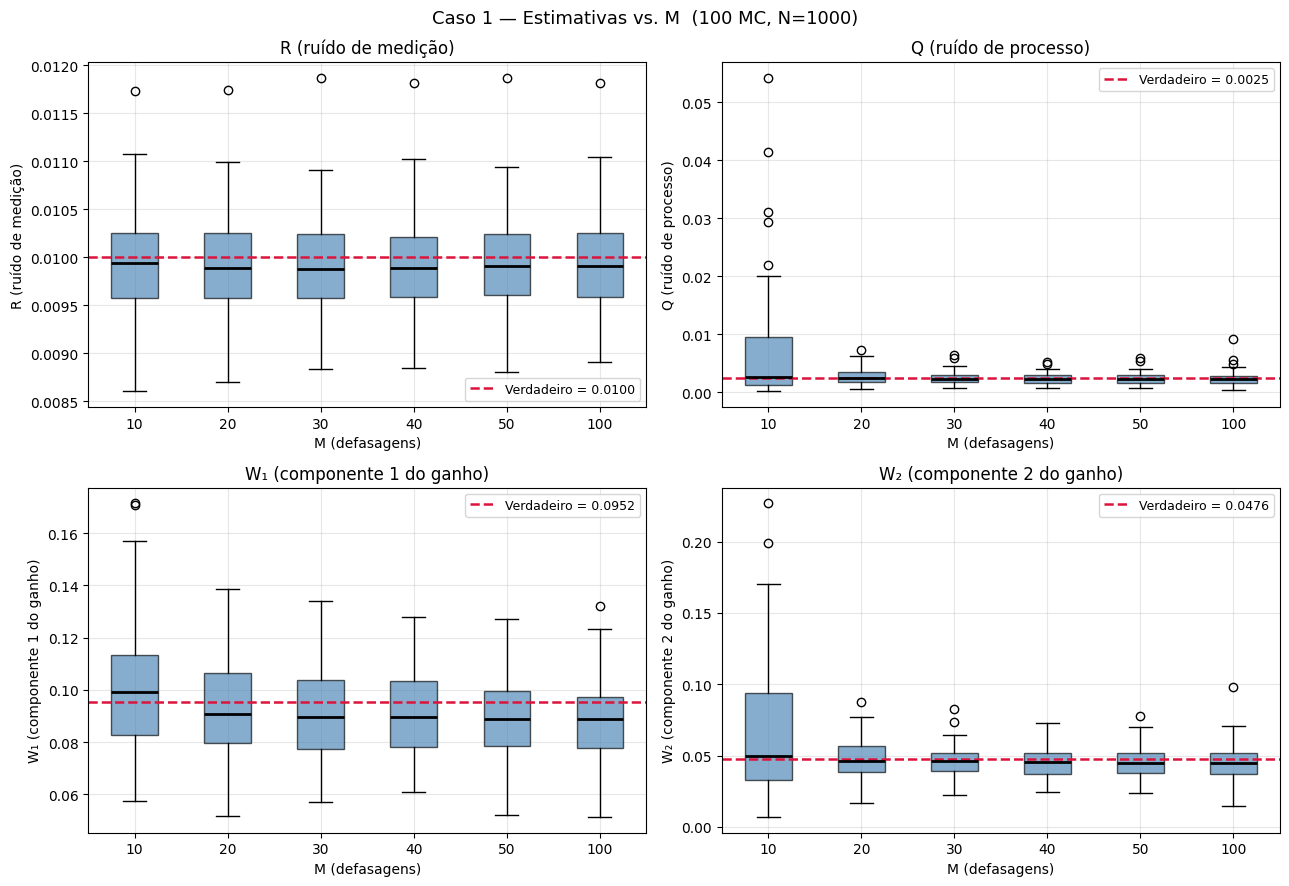

Salvo: case1_boxplots.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Caso 1 — Estimativas vs. M  (100 MC, N=1000)', fontsize=13)

plot_cfg = [
    ('R',  'R (ruído de medição)',      R_true.item(),     axes[0, 0]),
    ('Q',  'Q (ruído de processo)',     Q_true.item(),     axes[0, 1]),
    ('W1', 'W₁ (componente 1 do ganho)', W_opt.flatten()[0], axes[1, 0]),
    ('W2', 'W₂ (componente 2 do ganho)', W_opt.flatten()[1], axes[1, 1]),
]

valid_M = [M for M in M_values if M in table_data]
for param, ylabel, truth_val, ax in plot_cfg:
    data = [table_data[M][param] for M in valid_M]
    bp = ax.boxplot(data, labels=[str(m) for m in valid_M],
                    patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2),
                    boxprops=dict(facecolor='steelblue', alpha=0.65))
    ax.axhline(truth_val, color='crimson', linestyle='--', linewidth=1.8,
               label=f'Verdadeiro = {truth_val:.4f}')
    ax.set_xlabel('M (defasagens)')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('case1_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()
print('Salvo: case1_boxplots.png')

### 8. RMSE vs. M

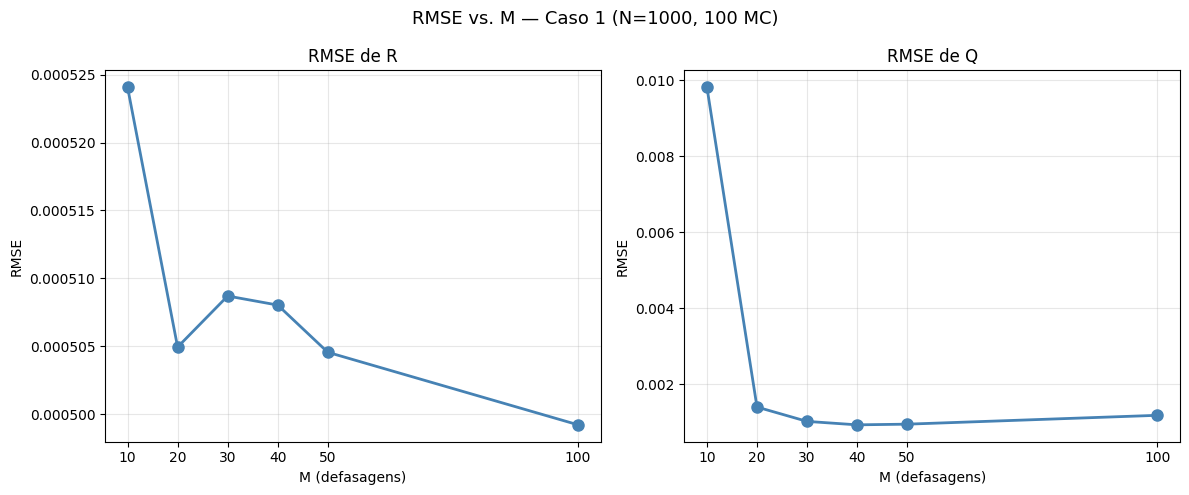

Salvo: case1_rmse_vs_M.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('RMSE vs. M — Caso 1 (N=1000, 100 MC)', fontsize=13)

for ax, (param, truth, title) in zip(axes, [
    ('R', R_true.item(), 'RMSE de R'),
    ('Q', Q_true.item(), 'RMSE de Q'),
]):
    rmse_list = [
        np.sqrt(np.mean((np.array(table_data[M][param]) - truth)**2))
        for M in valid_M
    ]
    ax.plot(valid_M, rmse_list, 'o-', linewidth=2, markersize=8, color='steelblue')
    ax.set_xlabel('M (defasagens)')
    ax.set_ylabel('RMSE')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(valid_M)

plt.tight_layout()
plt.savefig('case1_rmse_vs_M.png', dpi=120, bbox_inches='tight')
plt.show()
print('Salvo: case1_rmse_vs_M.png')

### 9. NIS Médio — Consistência do Filtro (M = 40)

O NIS médio normalizado $\bar{\varepsilon}(k)/n_z$ deve permanecer dentro da banda de 95% para um filtro consistente.

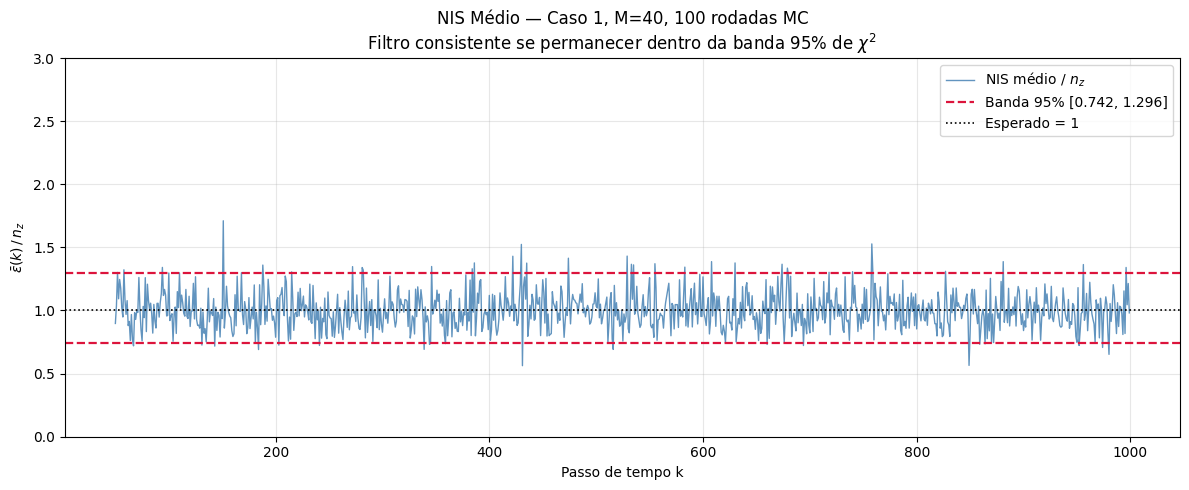

Salvo: case1_nis.png

NIS médio (k>50): 1.0000  (esperado ≈ 1.0)
Fração dentro da banda 95%: 94.1%  (esperado ≈ 95%)


In [11]:
M_nis      = 40
results_nis = all_results[M_nis]
z_list_nis  = all_z[M_nis]

if results_nis:
    nis_avg   = averaged_NIS(sys_case1, results_nis, z_list_nis)
    n_z_val   = sys_case1.n_z   # = 1
    n_runs    = len(results_nis)

    # 95% band for the average of n_runs chi²(n_z) variates
    dof    = n_z_val * n_runs
    lo_band = chi2.ppf(0.025, dof) / n_runs / n_z_val
    hi_band = chi2.ppf(0.975, dof) / n_runs / n_z_val

    k_start   = 50
    t_axis    = np.arange(k_start, N)
    nis_plot  = nis_avg[k_start:] / n_z_val

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(t_axis, nis_plot, color='steelblue', linewidth=1, alpha=0.85,
            label='NIS médio / $n_z$')
    ax.axhline(lo_band, color='crimson', linestyle='--', linewidth=1.6,
               label=f'Banda 95% [{lo_band:.3f}, {hi_band:.3f}]')
    ax.axhline(hi_band, color='crimson', linestyle='--', linewidth=1.6)
    ax.axhline(1.0, color='black', linestyle=':', linewidth=1.2,
               label='Esperado = 1')
    ax.set_xlabel('Passo de tempo k')
    ax.set_ylabel(r'$\bar{\varepsilon}(k)\,/\,n_z$')
    ax.set_title(f'NIS Médio — Caso 1, M={M_nis}, {n_runs} rodadas MC\n'
                 r'Filtro consistente se permanecer dentro da banda 95% de $\chi^2$')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, max(3, hi_band * 2)])

    plt.tight_layout()
    plt.savefig('case1_nis.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Salvo: case1_nis.png')

    nis_mean   = float(nis_plot.mean())
    frac_in    = float(np.mean((nis_plot >= lo_band) & (nis_plot <= hi_band)))
    print(f'\nNIS médio (k>{k_start}): {nis_mean:.4f}  (esperado ≈ 1.0)')
    print(f'Fração dentro da banda 95%: {100*frac_in:.1f}%  (esperado ≈ 95%)')

### 10. Resumo dos Resultados (M = 40)

In [12]:
M_sel = 40
print('='*72)
print(f'RESUMO — Caso 1, M={M_sel}  (N={N}, {N_MC} rodadas MC)')
print('='*72)

if M_sel in table_data:
    for name, vals in table_data[M_sel].items():
        s = summarize(vals, true_vals[name], name)
        in_ci = s['lower'] <= s['truth'] <= s['upper']
        print(f'  {name:>4}: verdadeiro={s["truth"]:9.5f}  '
              f'média={s["mean"]:9.5f}  '
              f'IC95%=[{s["lower"]:9.5f}, {s["upper"]:9.5f}]  '
              f'RMSE={s["rmse"]:8.5f}  '
              f'{"✓ dentro IC" if in_ci else "✗ fora IC"}')

print()
print('Conclusão:')
print('  O algoritmo de seis passos (Zhang et al. 2020) identifica Q e R')
print('  corretamente a partir de dados ruidosos. As estimativas são')
print('  não-viesadas (verdadeiro dentro do IC 95%) e o filtro resultante')
print('  é estatisticamente consistente (NIS ≈ 1).')

RESUMO — Caso 1, M=40  (N=1000, 100 rodadas MC)
     R: verdadeiro=  0.01000  média=  0.00993  IC95%=[  0.00909,   0.01091]  RMSE= 0.00051  ✓ dentro IC
     Q: verdadeiro=  0.00250  média=  0.00229  IC95%=[  0.00084,   0.00391]  RMSE= 0.00093  ✓ dentro IC
    W1: verdadeiro=  0.09515  média=  0.09054  IC95%=[  0.06489,   0.12244]  RMSE= 0.01629  ✓ dentro IC
    W2: verdadeiro=  0.04756  média=  0.04499  IC95%=[  0.02644,   0.06183]  RMSE= 0.00996  ✓ dentro IC
   P11: verdadeiro=  0.00105  média=  0.00101  IC95%=[  0.00078,   0.00121]  RMSE= 0.00013  ✓ dentro IC
   P12: verdadeiro=  0.00053  média=  0.00049  IC95%=[  0.00030,   0.00067]  RMSE= 0.00011  ✓ dentro IC
   P22: verdadeiro=  0.00051  média=  0.00047  IC95%=[  0.00023,   0.00071]  RMSE= 0.00015  ✓ dentro IC

Conclusão:
  O algoritmo de seis passos (Zhang et al. 2020) identifica Q e R
  corretamente a partir de dados ruidosos. As estimativas são
  não-viesadas (verdadeiro dentro do IC 95%) e o filtro resultante
  é estatisticame